# 04. Modelagem Econométrica: Regressão Linear Simples e Sazonal das Rotas Líderes

**Documentação da Etapa**
* **Objetivo da etapa:** Ajustar modelos de regressão linear simples e modelos sazonais com dummies mensais e tendência temporal para as rotas líderes (Top 1) de cada município e fluxo comercial.
* **Dados de entrada:** Base mensal agregada das rotas líderes (`data/processed/df_sazonal_lideres.csv`).
* **Procedimentos realizados:**
  1. Configuração do ambiente e carregamento das funções em `R/regressoes.R`.
  2. Ajuste e avaliação da Regressão Linear Simples ($Volume \sim \text{Valor\_FOB}$).
  3. Diagnóstico gráfico de resíduos e aderência temporal do modelo simples.
  4. Ajuste e avaliação da Regressão Múltipla com Sazonalidade ($Volume \sim t + \text{Dummies\_Mês}$).
  5. Diagnóstico gráfico de resíduos e aderência temporal do modelo sazonal múltiplo.

### configurações

In [1]:
# ==============================================================================
# Setup, Carregamento de Bibliotecas, Funções e Base de Dados
# ==============================================================================
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(scales)
library(fs)

# 1. Determina dinamicamente o caminho da raiz do projeto
caminho_atual <- getwd()
raiz_projeto <- ifelse(basename(caminho_atual) == "notebooks", path_dir(caminho_atual), caminho_atual)

# 2. Carrega as funções do script modular de regressão
source(path(raiz_projeto, "R", "regressoes.R"))

# 3. Carrega a base sazonal das rotas líderes (Top 1)
caminho_csv <- path(raiz_projeto, "data", "processed", "df_sazonal_lideres.csv")
df_sazonal_lideres <- read_csv2(caminho_csv, show_col_types = FALSE)

# 4. Configuração visual de números no console
options(scipen = 999, digits = 3)

cat(sprintf("Ambiente configurado com sucesso! Base carregada com %d agregações mensais.\n", nrow(df_sazonal_lideres)))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Ambiente configurado com sucesso! Base carregada com 481 agregações mensais.


## 1. Regressão Linear Simples por Rota Líder

**Conceito e Aplicação Metodológica:**
A **Regressão Linear Simples** busca estimar a relação funcional direta entre uma variável explicativa contínua e uma variável dependente quantitativa via Mínimos Quadrados Ordinários (OLS):

$$Volume_t = \beta_0 + \beta_1 \cdot \text{Valor\_FOB}_t + \varepsilon_t$$

* **O que avalia:** Mede a elasticidade/intensidade da movimentação física de carga ($k\text{ ton}$) em resposta direta ao valor monetário transacionado em dólares livres a bordo ($\text{Milhões de US\$ FOB}$).
* **Aplicação no Projeto:** O modelo foi ajustado de forma segmentada para cada uma das **6 rotas líderes (Top 1)** identificadas pelo princípio de Pareto nos fluxos de importação e exportação dos municípios polo. O objetivo é avaliar a sensibilidade de preço/volume ($b_1$) e a precisão do ajuste ($R^2$ e $\text{RMSE}$) individualmente para os principais produtos comercializados.

### Aplicação da Regressão Linear Simples

In [2]:
# Ajuste dos modelos OLS simples para todas as rotas líderes
regressao_rotas <- ajustar_regressao_top1_rotas(df_sazonal_lideres)

# Exibição das métricas consolidadas
regressao_rotas$metricas |>
  mutate(`Descrição Curta` = str_trunc(`Descrição SH4`, 25)) |>
  select(
    Fluxo, Município, País, `Produto` = `Descrição Curta`,
    N, `β₀ (Intercepto)` = Intercepto_b0, `β₁ (Inclinação)` = Inclinacao_b1,
    `R²` = R2, `R² Ajustado` = R2_Ajustado, `RMSE (k ton)` = RMSE_Mil_Ton, `p-valor` = p_valor
  ) |>
  as.data.frame()

Fluxo,Município,País,Produto,N,β₀ (Intercepto),β₁ (Inclinação),R²,R² Ajustado,RMSE (k ton),p-valor
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Exportação,Cubatão - SP,China,"Soja, mesmo triturada",78,4.84,1.96,0.925,0.924,10.62,<0.001
Exportação,Guarujá - SP,China,"Soja, mesmo triturada",76,14.49,2.00,0.891,0.890,33.16,<0.001
Exportação,Santos - SP,China,"Soja, mesmo triturada",86,14.21,2.09,0.917,0.916,50.99,<0.001
Importação,Cubatão - SP,Chile,Sal (incluídos o sal d...,71,2.52,41.50,0.822,0.820,7.09,<0.001
Importação,Guarujá - SP,Estados Unidos,Hidróxido de sódio (so...,82,6.59,4.40,0.775,0.772,7.59,<0.001
Importação,Santos - SP,Argentina,Trigo e mistura de tri...,88,10.86,2.88,0.757,0.754,10.52,<0.001


Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall,

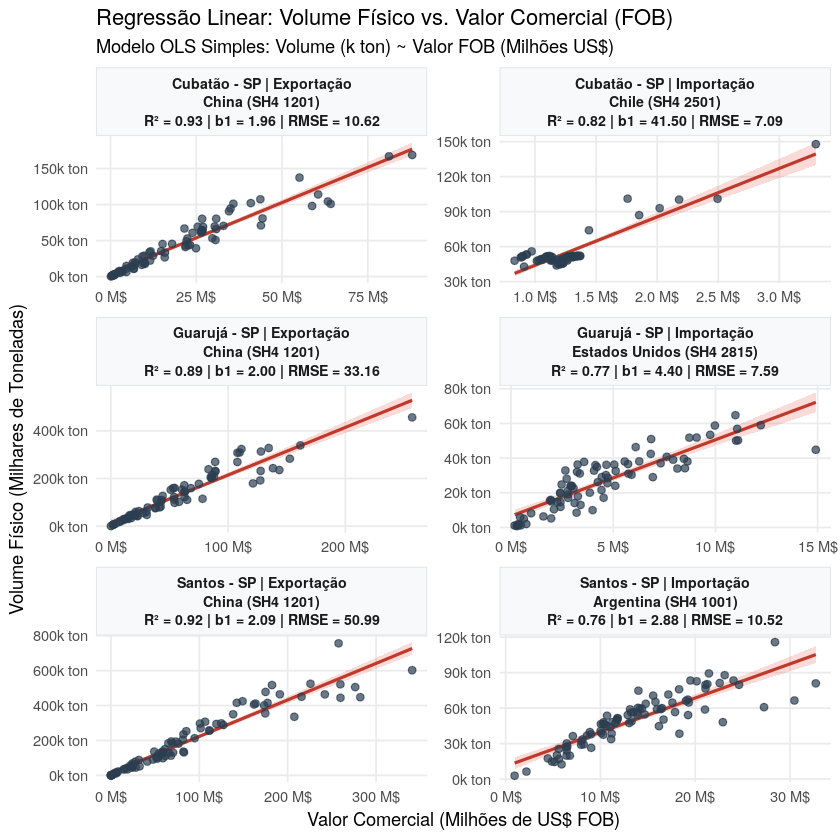

In [3]:
# Visualização dos diagramas de dispersão com retas OLS ajustadas
plotar_regressao_top1_rotas(regressao_rotas)

### Avaliação da Regressão Simples através dos Gráficos de Resíduos

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


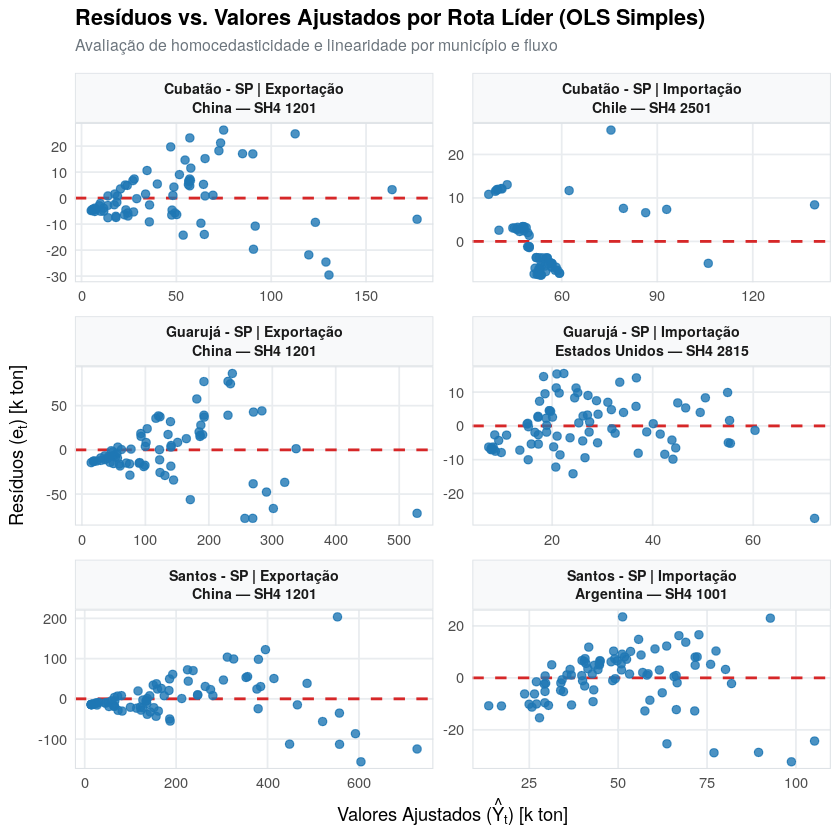

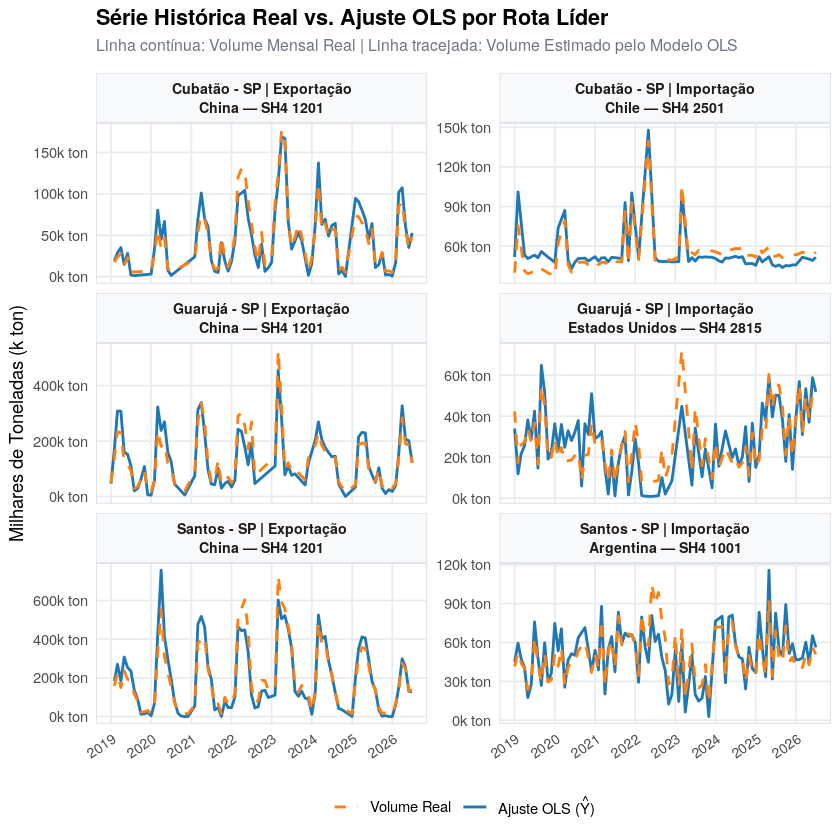

In [4]:
# 1. Extração dos resíduos e valores ajustados do modelo OLS simples
df_diagnostico_rotas <- obter_dados_diagnostico_rotas(regressao_rotas)

# 2. Gráfico Resíduos vs. Valores Ajustados (6 rotas)
p_residuos_ols <- plotar_todos_residuos_vs_ajustados(df_diagnostico_rotas)
print(p_residuos_ols)

# 3. Gráfico Série Histórica Real vs. Ajuste OLS no tempo (6 rotas)
p_series_ols <- plotar_todas_series_reais_vs_ajustadas(df_diagnostico_rotas)
print(p_series_ols)

## 2. Regressão Linear Múltipla com Dummies Sazonais e Tendência

**Conceito e Aplicação Metodológica:**
A **Regressão Linear Múltipla com Variáveis Dummy** expande a análise temporal incorporando uma tendência contínua ($t$) e variáveis binárias de efeito fixo para capturar os ciclos de sazonalidade ao longo do ano:

$$Volume_t = \beta_0 + \beta_{tempo} \cdot t + \sum_{m=2}^{12} \gamma_m \cdot D_{m,t} + \varepsilon_t$$

* **O que avalia:** Permite isolar o crescimento linear estrutural da rota ao longo do período histórico (2019–2026) e quantificar o impacto médio específico de cada mês ($D_{2}, \dots, D_{12}$) em relação ao mês base de referência (**Janeiro**).
* **Aplicação no Projeto:** O modelo é ajustado sobre a série mensal agregada das 6 rotas líderes, identificando meses de pico e entressafra na movimentação portuária de granéis e químicos sem impor um formato rígido à curva de demanda anual.

### Aplicação da Regressão Linear Múltipla

In [5]:
# Ajuste do modelo com dummies mensais e tendência temporal contínua
regressao_dummies <- ajustar_regressao_dummies_rotas(df_sazonal_lideres)

# Tabela consolidada com as métricas do modelo sazonal múltiplo
regressao_dummies$metricas |>
  mutate(`Descrição Curta` = str_trunc(`Descrição SH4`, 25)) |>
  select(
    Fluxo, Município, País, `Produto` = `Descrição Curta`,
    N, `R²`, `R² Ajustado` = `R²_Ajustado`, `RMSE (k ton)` = RMSE_Mil_Ton, 
    `p-valor` = p_valor
  ) |>
  as.data.frame()

Fluxo,Município,País,Produto,N,R²,R² Ajustado,RMSE (k ton),p-valor
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>
Exportação,Cubatão - SP,China,"Soja, mesmo triturada",78,0.608,0.5360,24.4,<0.001
Exportação,Guarujá - SP,China,"Soja, mesmo triturada",76,0.768,0.7240,48.4,<0.001
Exportação,Santos - SP,China,"Soja, mesmo triturada",86,0.785,0.7502,81.8,<0.001
Importação,Cubatão - SP,Chile,Sal (incluídos o sal d...,71,0.165,-0.0076,15.4,0.5
Importação,Guarujá - SP,Estados Unidos,Hidróxido de sódio (so...,82,0.110,-0.0454,15.1,0.74
Importação,Santos - SP,Argentina,Trigo e mistura de tri...,88,0.195,0.0658,19.2,0.139


In [6]:
# Inspeção dos coeficientes e efeitos mensais da primeira rota líder
summary(regressao_dummies$modelos[[1]])


Call:
lm(formula = volume_mil_ton ~ tempo + mes_nome_fator, data = dados_rota)

Residuals:
   Min     1Q Median     3Q    Max 
 -49.0  -14.8   -1.0   14.3   87.2 

Coefficients:
                        Estimate Std. Error t value  Pr(>|t|)    
(Intercept)               -5.071     13.056   -0.39     0.699    
tempo                      0.422      0.137    3.09     0.003 ** 
mes_nome_fatorFevereiro   37.554     15.222    2.47     0.016 *  
mes_nome_fatorMarço       80.132     15.217    5.27 0.0000017 ***
mes_nome_fatorAbril       77.389     15.214    5.09 0.0000033 ***
mes_nome_fatorMaio        67.180     15.212    4.42 0.0000388 ***
mes_nome_fatorJunho       34.253     15.211    2.25     0.028 *  
mes_nome_fatorJulho       24.189     15.211    1.59     0.117    
mes_nome_fatorAgosto      14.399     16.156    0.89     0.376    
mes_nome_fatorSetembro     3.328     16.900    0.20     0.844    
mes_nome_fatorOutubro     17.524     16.908    1.04     0.304    
mes_nome_fatorNovembro    -5.

### Avaliação da Regressão Múltipla através dos Gráficos de Resíduos

Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”
Warning message in prettyNum(.Internal(format(x, trim, digits, nsmall, width, 3L, :
“'big.mark' and 'decimal.mark' are both '.', which could be confusing”


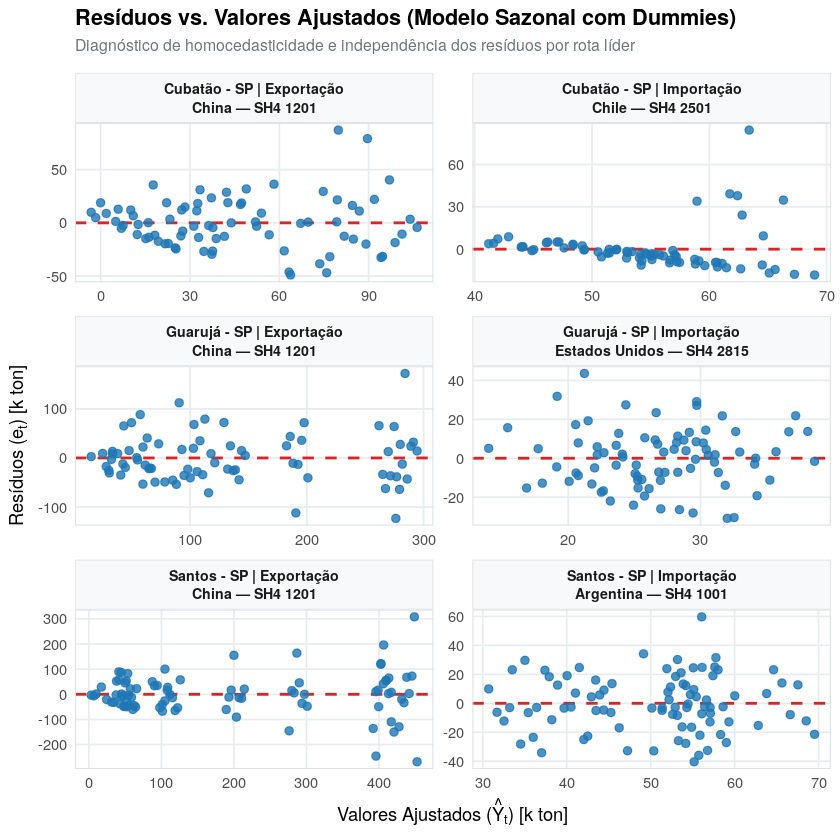

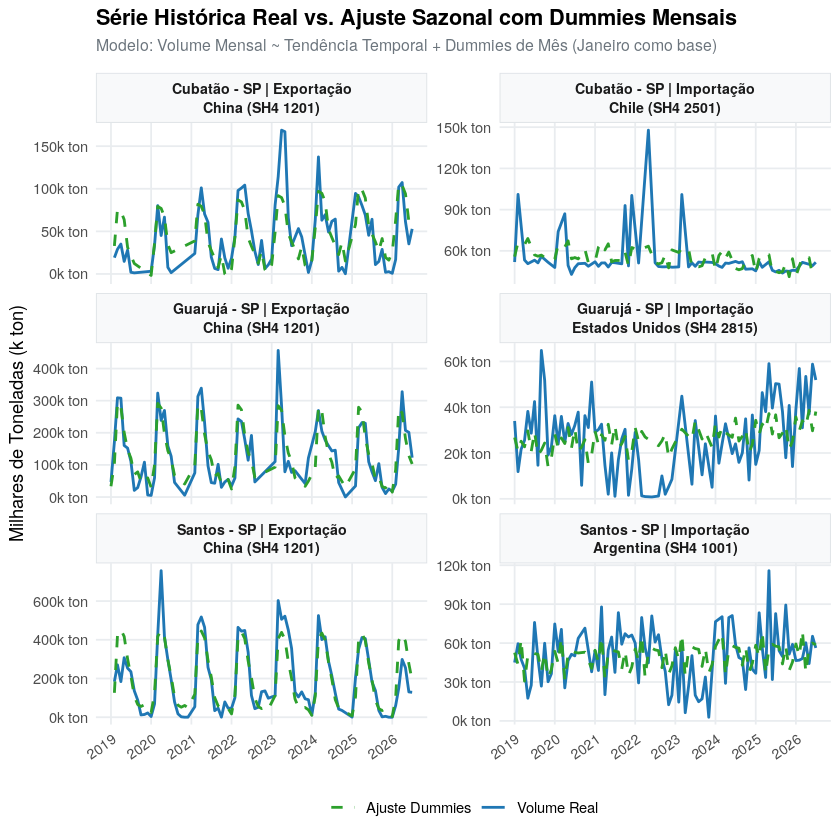

In [7]:
# 1. Extração dos resíduos e valores ajustados do modelo com dummies
df_diag_dummies <- obter_dados_diagnostico_dummies(regressao_dummies)

# 2. Gráfico Resíduos vs. Valores Ajustados do Modelo Sazonal (6 rotas)
p_residuos_dummies <- plotar_residuos_vs_ajustados_dummies(df_diag_dummies)
print(p_residuos_dummies)

# 3. Gráfico Série Histórica Real vs. Ajuste Sazonal com Dummies no tempo (6 rotas)
p_series_dummies <- plotar_regressao_dummies_rotas(regressao_dummies)
print(p_series_dummies)